# Suma de flujos diferenciales sin integrar

Este notebook suma los flujos diferenciales de todos los mesones en una malla común de energía y grafica el resultado.
No integra sobre energía.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cwd = '/home/lurishi/Escritorio/HeavenlyMCP/'
path = cwd + '/Data/MCP_flux/MCP_flux'

plt.rcParams.update({'font.family': 'serif'})

In [2]:
df_pi0_ = pd.read_csv('/home/lurishi/Escritorio/HeavenlyMCP/Data/MCP_flux/MCP_FROM_PI0_SURFACE.csv')
df_eta_ = pd.read_csv(path + '/MCP_FROM_ETA_SURFACE.csv')
df_omega_ = pd.read_csv(path + '/MCP_FROM_OMEGA_SURFACE.csv')
df_rho_ = pd.read_csv(path + '/MCP_FROM_RHO_SURFACE.csv')
df_phi_ = pd.read_csv(path + '/MCP_FROM_PHI_SURFACE.csv')
df_jpsi_ = pd.read_csv(path + '/MCP_FROM_JPSI_SURFACE.csv')

eps2 = 1e-4
cos_theta = 1.0

In [3]:
dfs = [
    df_pi0_[(df_pi0_['cosTh'] == cos_theta) & (df_pi0_['eps2'] == eps2)],
    df_eta_[(df_eta_['cosTh'] == cos_theta) & (df_eta_['eps2'] == eps2)],
    df_omega_[(df_omega_['cosTh'] == cos_theta) & (df_omega_['eps2'] == eps2)],
    df_rho_[(df_rho_['cosTh'] == cos_theta) & (df_rho_['eps2'] == eps2)],
    df_phi_[(df_phi_['cosTh'] == cos_theta) & (df_phi_['eps2'] == eps2)],
    df_jpsi_[(df_jpsi_['cosTh'] == cos_theta) & (df_jpsi_['eps2'] == eps2)],
]
meson_names = ['pi0', 'eta', 'omega', 'rho', 'phi', 'jpsi']

def sum_differential_flux_at_mass(dfs, mass_value):
    energy_grids = []
    differential_curves = []

    for df in dfs:
        subset = df[df['m(GeV)'] == mass_value]
        if subset.empty:
            continue

        energy = subset['Energy (GeV)'].to_numpy()
        differential = subset['dphi_dEdCth(1/GeV/s/cm2)'].to_numpy()
        order = np.argsort(energy)
        energy_grids.append(energy[order])
        differential_curves.append(differential[order])

    if not energy_grids:
        return None, None

    common_energy = np.unique(np.concatenate(energy_grids))
    total_differential = np.zeros_like(common_energy, dtype=float)

    for energy, differential in zip(energy_grids, differential_curves):
        total_differential += np.interp(common_energy, energy, differential, left=0.0, right=0.0)

    return common_energy, total_differential

all_masses = np.unique(np.concatenate([df['m(GeV)'].unique() for df in dfs]))
summed_spectra = []

for mass_value in all_masses:
    energy, total_differential = sum_differential_flux_at_mass(dfs, mass_value)
    if energy is None:
        continue
    summed_spectra.append((mass_value, energy, total_differential))

print('Masses available:', len(summed_spectra))
print('First mass:', summed_spectra[0][0] if summed_spectra else None)

Masses available: 84
First mass: 0.01


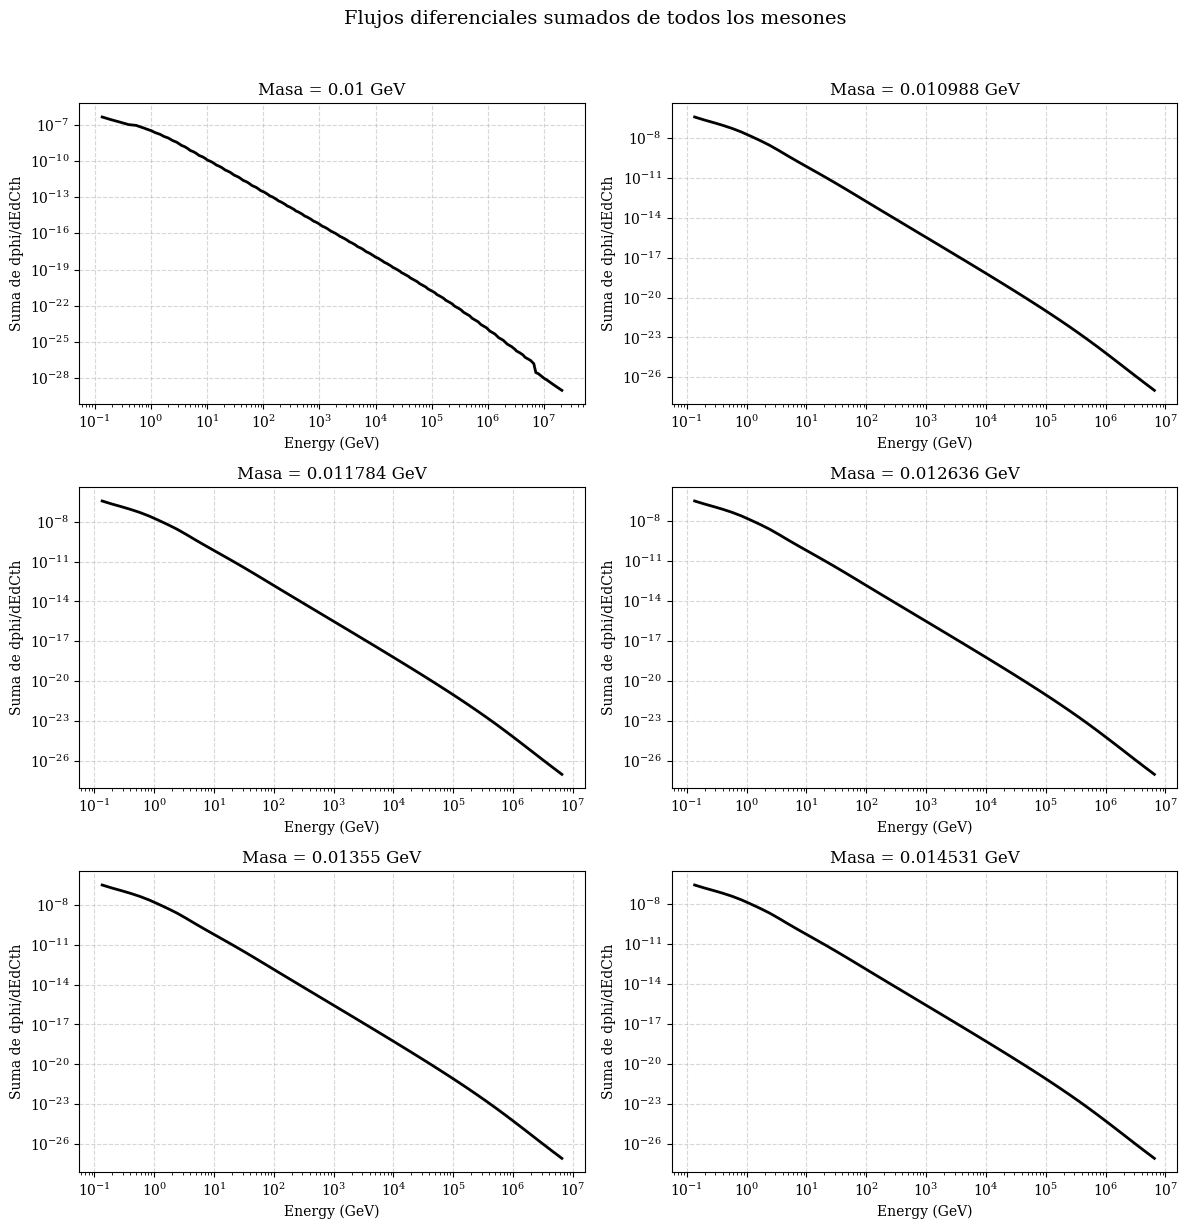

In [4]:
masses_to_plot = [mass for mass, _, _ in summed_spectra[:6]]
nplots = len(masses_to_plot)
ncols = 2
nrows = int(np.ceil(nplots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharex=False, sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, mass_value in zip(axes, masses_to_plot):
    energy, total_differential = next((e, d) for m, e, d in summed_spectra if m == mass_value)
    ax.plot(energy, total_differential, color='black', linewidth=2)
    ax.set_title(f'Masa = {mass_value:.6g} GeV')
    ax.set_xlabel('Energy (GeV)')
    ax.set_ylabel('Suma de dphi/dEdCth')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xscale('log')
    ax.set_yscale('log')

for ax in axes[nplots:]:
    ax.axis('off')

fig.suptitle('Flujos diferenciales sumados de todos los mesones', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

In [13]:
md_paper_0 = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/MD_cos_0.csv',sep = ';')
md_paper_1 = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/MD_cos_1.csv',sep = ';')
E_0 = md_paper_0[md_paper_0.columns[0]].to_numpy()
E_1 = md_paper_1[md_paper_1.columns[0]].to_numpy()
phi_dif_0 = md_paper_0[md_paper_0.columns[1]].to_numpy()
phi_dif_1 = md_paper_1[md_paper_1.columns[1]].to_numpy()

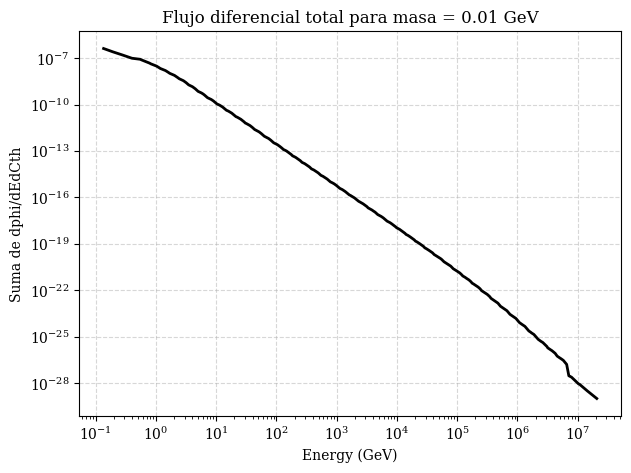

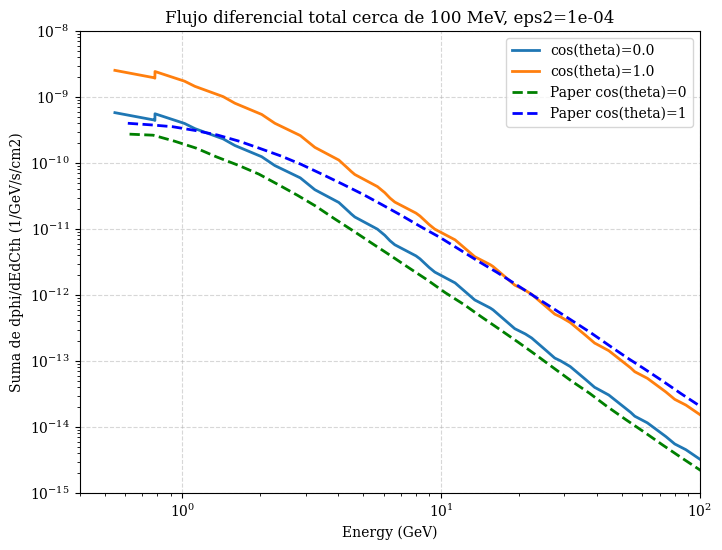

cos(theta)=0.0: masa seleccionada = 0.1 GeV, mesones = eta, omega, rho, phi, jpsi
cos(theta)=1.0: masa seleccionada = 0.1 GeV, mesones = eta, omega, rho, phi, jpsi


In [17]:
# Si quieres graficar una sola masa, cambia mass_value por el valor deseado.
mass_value = summed_spectra[0][0]
energy, total_differential = next((e, d) for m, e, d in summed_spectra if m == mass_value)

plt.figure(figsize=(7, 5))
plt.plot(energy, total_differential, color='black', linewidth=2)
plt.xlabel('Energy (GeV)')
plt.ylabel('Suma de dphi/dEdCth')
plt.title(f'Flujo diferencial total para masa = {mass_value:.6g} GeV')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

target_mass_mev = 100.0
target_mass_gev = target_mass_mev / 1000.0
cos_theta_values = [0.0, 1.0]

raw_dfs = {
    'pi0': df_pi0_,
    'eta': df_eta_,
    'omega': df_omega_,
    'rho': df_rho_,
    'phi': df_phi_,
    'jpsi': df_jpsi_,
}

def build_total_differential_spectrum(cos_theta_value, eps2_value, target_mass_value_gev):
    selected_dfs = [
        df[(df['cosTh'] == cos_theta_value) & (df['eps2'] == eps2_value)]
        for df in raw_dfs.values()
    ]
    available_masses = np.unique(np.concatenate([df['m(GeV)'].unique() for df in selected_dfs if not df.empty]))
    if len(available_masses) == 0:
        return None, None, None, None

    selected_mass = available_masses[np.argmin(np.abs(available_masses - target_mass_value_gev))]

    energy_grids = []
    differential_curves = []
    contributing_mesons = []

    for meson_name, df in raw_dfs.items():
        subset = df[(df['cosTh'] == cos_theta_value) & (df['eps2'] == eps2_value) & (df['m(GeV)'] == selected_mass)]
        if subset.empty:
            continue

        energy = subset['Energy (GeV)'].to_numpy()
        differential = subset['dphi_dEdCth(1/GeV/s/cm2)'].to_numpy()
        order = np.argsort(energy)
        energy_grids.append(energy[order])
        differential_curves.append(differential[order])
        contributing_mesons.append(meson_name)

    if not energy_grids:
        return selected_mass, None, None, None

    common_energy = np.unique(np.concatenate(energy_grids))
    total_differential = np.zeros_like(common_energy, dtype=float)

    for energy, differential in zip(energy_grids, differential_curves):
        total_differential += np.interp(common_energy, energy, differential, left=0.0, right=0.0)

    return selected_mass, common_energy, total_differential, contributing_mesons

fig, ax = plt.subplots(figsize=(8, 6))
summary_lines = []

for cos_theta_value, color in zip(cos_theta_values, ['tab:blue', 'tab:orange']):
    selected_mass, energy, total_differential, contributing_mesons = build_total_differential_spectrum(
        cos_theta_value, eps2, target_mass_gev
    )

    if energy is None:
        summary_lines.append(f'cos(theta)={cos_theta_value}: no data found')
        continue

    ax.plot(energy, total_differential, color=color, linewidth=2, label=f'cos(theta)={cos_theta_value}')
    meson_list = ', '.join(contributing_mesons)
    summary_lines.append(
        f'cos(theta)={cos_theta_value}: masa seleccionada = {selected_mass:.6g} GeV, mesones = {meson_list}'
    )

ax.set_xlabel('Energy (GeV)')
ax.set_ylabel('Suma de dphi/dEdCth (1/GeV/s/cm2)')
ax.set_title(f'Flujo diferencial total cerca de {target_mass_mev:.0f} MeV, eps2={eps2:.0e}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(4e-1, 1e2)
ax.set_ylim(1e-15, 1e-8)
ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(E_0, phi_dif_0, color='green', linestyle='--', linewidth=2, label='Paper cos(theta)=0')
ax.plot(E_1, phi_dif_1, color='blue', linestyle='--', linewidth=2, label='Paper cos(theta)=1')
ax.legend()
plt.show()

for line in summary_lines:
    print(line)